In [ ]:
import os
import gc
import re
import glob
import tqdm
import pickle
from os.path import exists

import scanpy as sc
import cell2fate as c2f
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import torch

from scipy.stats import rankdata
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import cophenet
from itertools import product
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from itertools import combinations
from scipy.stats import spearmanr
from scipy.stats import zscore

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def calculate_overlap(data, N_genes):
    # Concatenate all numerical data
    input_mat = []
    for m in data.columns:
        s = data[m].head(N_genes)
        s.name = m
        input_mat.append(pd.DataFrame({m:True}, index=s))
    input_mat = pd.concat(input_mat, axis=1).fillna(False)

    return input_mat

def _cluster_distance_avg(D, idx_points, idx_cluster):
    # returns array len(idx_points)
    return D[np.ix_(idx_points, idx_cluster)].mean(axis=1)

def _relabel_compact(labels):
    uniq = np.unique(labels)
    mapping = {old: new for new, old in enumerate(uniq)}
    return np.array([mapping[x] for x in labels], dtype=int)

def hca_groups_sklearn_approx(
    D,                 # precomputed distance matrix (n x n)
    k,
    min_size=4,
    max_frac=0.5,
    linkage="complete",
    max_iter=10,
    random_state=None, # unused, but kept for API symmetry
):

    D = np.asarray(D)
    n = D.shape[0]
    assert D.shape == (n, n), "D must be square (n x n)"
    max_size = int(np.floor(max_frac * n))
    max_size = max(max_size, min_size)  # avoid impossible constraints

    # --- 1) Base clustering ---
    base = AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage=linkage,
        compute_full_tree=True
    )
    labels = base.fit_predict(D)
    labels = _relabel_compact(labels)

    def sizes(lbls):
        u, c = np.unique(lbls, return_counts=True)
        return dict(zip(u, c))

    for _ in range(max_iter):
        changed = False
        sz = sizes(labels)

        # --- 2) Split oversized clusters ---
        big = [cid for cid, s in sz.items() if s > max_size]
        for cid in big:
            members = np.where(labels == cid)[0]
            s = len(members)
            # number of subclusters to bring each <= max_size
            n_sub = int(np.ceil(s / max_size))
            if n_sub <= 1:
                continue

            subD = D[np.ix_(members, members)]
            sub_model = AgglomerativeClustering(
                n_clusters=n_sub,
                metric="precomputed",
                linkage=linkage,
                compute_full_tree=True
            )
            sub_labels = sub_model.fit_predict(subD)

            # map subclusters to new global ids
            next_id = labels.max() + 1
            for sub in np.unique(sub_labels):
                sub_members = members[sub_labels == sub]
                # keep one subcluster as the original cid; others get new ids
                if sub == 0:
                    labels[sub_members] = cid
                else:
                    labels[sub_members] = next_id
                    next_id += 1

            labels = _relabel_compact(labels)
            changed = True

        # recompute after splits
        sz = sizes(labels)

        # --- 3) Merge undersized clusters ---
        small = [cid for cid, s in sz.items() if s < min_size]
        if small:
            # candidates to absorb into = clusters that are already >= min_size
            # (or if none, absorb into largest)
            sz = sizes(labels)
            eligible = [cid for cid, s in sz.items() if s >= min_size]
            if not eligible:
                eligible = [max(sz, key=sz.get)]

            for cid in small:
                members = np.where(labels == cid)[0]
                if len(members) == 0:
                    continue

                # compute best target cluster per point
                targets = []
                for p in members:
                    # average distance from this point to each eligible cluster
                    d_to = []
                    for tgt in eligible:
                        tgt_members = np.where(labels == tgt)[0]
                        d_to.append((tgt, D[p, tgt_members].mean()))
                    tgt_best = min(d_to, key=lambda x: x[1])[0]
                    targets.append(tgt_best)

                # reassign
                labels[members] = np.array(targets, dtype=int)
                labels = _relabel_compact(labels)
                changed = True

        # stop if stable and constraints met
        sz = sizes(labels)
        ok = all(s >= min_size for s in sz.values()) and all(s <= max_size for s in sz.values())
        if ok:
            break
        if not changed:
            break

    return labels

palette_25 = [
    "#ffd92f",  # yellow
    "#bcbd22",  # olive

    "#ff7f0e",  # orange

    "#d62728",  # red
    "#e377c2",  # pink
    "#8c564b",  # brown
    "#9467bd",  # purple

    "#2ca02c",  # green
    "#7f7f7f",  # gray

    "#17becf",  # cyan
    "#003f5c",  # dark blue
    "#ffa600",  # amber
    "#2f4b7c",  # indigo
    "#a05195",  # magenta
    "#665191",  # violet
    "#d45087",  # rose
    "#f95d6a",  # coral
    "#00cc99",  # teal-green

    # --- added colors ---
    "#66c2a5",  # mint
    "#fc8d62",  # peach
    "#8da0cb",  # lavender-blue
    "#e78ac3",  # light pink
    "#a6d854",  # lime
    "#e5c494",  # sand
]

from matplotlib.colors import ListedColormap
cmap25 = ListedColormap(palette_25, name="distinct25")

Global seed set to 0


In [ ]:
data_dir = '../data/GBM/'
clone_dir = '../data/GBM/clones/'
save_dir = '../data/cell2fate/'

patients = np.array(('at12', 'at14', 'at4', 'at6', 'at9', 'at11', 
                     'at13', 'at15', 'at5', 'at7', 'at10', 'at3'))

passing_clones = ['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_9',
 'at5_4',
 'at5_2',
 'at9_4',
 'at9_0',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']
good_clones = [i.upper() for i in good_clones]

# Load ranked genes from modules

In [ ]:
# Path where the CSV files are located
path = '../data/trajectories/'

# Dictionary to hold dataframes
dfs = {}

# Get a list of all the CSV files
os.chdir(path)
files = glob.glob('*.csv')
files = [i for i in files if 'res_tab' in i]

print(files)
# Loop through the files and read them into a dataframe
for file in files:
    if True:
        # The key for the dictionary is the filename without the extension
        key = os.path.splitext(file)[0]
        key = str(key)
        key = re.sub('_2_res.*$', '', key).upper()

        df = pd.read_csv(file, index_col=0)

        module_genes_dict = {}

        module_genes=[]

        for i in range(len(df['Genes Ranked'])):
            module_genes = df['Genes Ranked'][i].split(',')
            for k in range(len(module_genes)):
                module_genes[k]=module_genes[k].split(' ')[-1]

            module_genes_dict[f'{i}'] = module_genes

        df_keys = pd.DataFrame(module_genes_dict)

        # Add the dataframe to the dictionary
        dfs[key] = df_keys

# Concatenate all numerical data
all_data = pd.concat([df.add_prefix(key + '_') for key, df in dfs.items()], axis=1)

['at4_0_2_res_tab.csv', 'at11_3_2_res_tab.csv', 'at6_3_2_res_tab.csv', 'at12_0_2_res_tab.csv', 'at12_5_2_res_tab.csv', 'at5_6_2_res_tab.csv', 'at7_1_2_res_tab.csv', 'at13_1_2_res_tab.csv', 'at15_2_2_res_tab.csv', 'at10_1_2_res_tab.csv', 'at10_3_2_res_tab.csv', 'at7_0_2_res_tab.csv', 'at4_3_2_res_tab.csv', 'at14_2_2_res_tab.csv', 'at9_0_2_res_tab.csv', 'at3_5_2_res_tab.csv', 'at11_1_2_res_tab.csv', 'at3_0_2_res_tab.csv', 'at5_9_2_res_tab.csv', 'at5_5_2_res_tab.csv', 'at5_4_2_res_tab.csv', 'at5_10_2_res_tab.csv', 'at6_1_2_res_tab.csv', 'at15_7_2_res_tab.csv', 'at9_3_2_res_tab.csv', 'at9_4_2_res_tab.csv', 'at11_0_2_res_tab.csv', 'at3_2_2_res_tab.csv', 'at15_1_2_res_tab.csv', 'at6_4_2_res_tab.csv', 'at15_6_2_res_tab.csv', 'at12_4_2_res_tab.csv', 'at6_0_2_res_tab.csv', 'at11_4_2_res_tab.csv', 'at5_0_2_res_tab.csv', 'at15_5_2_res_tab.csv', 'at6_7_2_res_tab.csv', 'at12_1_2_res_tab.csv', 'at14_3_2_res_tab.csv', 'at3_3_2_res_tab.csv', 'at10_0_2_res_tab.csv', 'at9_5_2_res_tab.csv', 'at9_2_2_res_

In [ ]:
good_clone_modules = [
    x for x in all_data.columns
    if any(p in x for p in good_clones)
]

all_data = all_data[good_clone_modules]

# Clustering

In [ ]:
params = []
output = {}
gs = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
for top_N in gs:
    top_genes = calculate_overlap(all_data, top_N)
    
    D = pairwise_distances(top_genes.T.to_numpy(), metric="manhattan")
    
    ks = range(2, min(30, D.shape[0]))  # edit upper bound if you want
    
    scores = []
    output[top_N] = {}
    for k in ks:
        labels = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage="complete",
        ).fit_predict(D)
    
        # silhouette needs >1 cluster and <n clusters (always true here) + no singleton-only issues ideally
        s = silhouette_score(D, labels, metric="precomputed")
        params.append(pd.DataFrame({'genes':top_N, 'k':k, 'score':s}, index=[0]))
        output[top_N][k] = labels
params = pd.concat(params, ignore_index=True)

<AxesSubplot:xlabel='k', ylabel='genes'>

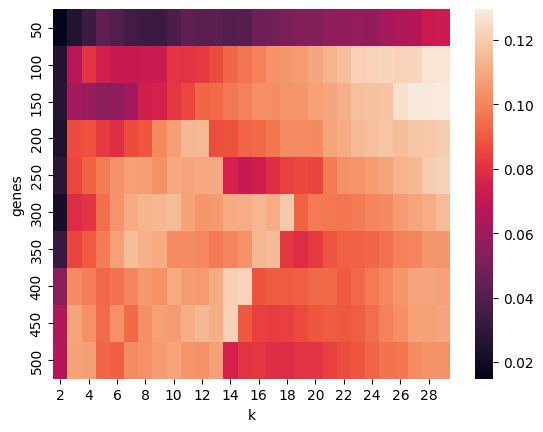

In [ ]:
sns.heatmap(params.pivot(index = 'genes', 
                         columns = 'k', 
                         values = 'score'))

In [ ]:
dendro_stability = []
gs = [50, 100, 150, 200, 250, 300, 350, 400, 
      450, 500, 550, 600, 700, 800, 900, 1000]
for top_N in gs:
    top_genes = calculate_overlap(all_data, top_N)
    
    D = pdist(top_genes.T.to_numpy(), metric="jaccard")
    
    Z = linkage(D, method="complete")
    
    ccc, coph_dists = cophenet(Z, D)
    dendro_stability.append(pd.DataFrame({'ccc':ccc, 'N':top_N}, index=[0]))
dendro_stability = pd.concat(dendro_stability, ignore_index=True)

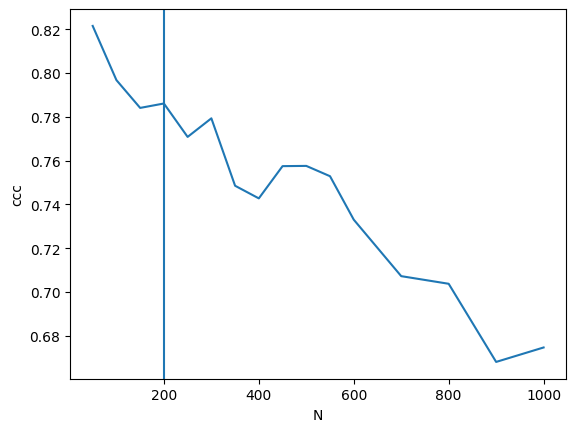

In [ ]:
sns.lineplot(data=dendro_stability, x = 'N', y = 'ccc')
plt.axvline(200)

In [ ]:
top_N = 200

params_1d = []
output = {}
top_genes = calculate_overlap(all_data, top_N)
    
D = pairwise_distances(top_genes.T.to_numpy(), metric="manhattan")
    
ks = range(2, min(30, D.shape[0]))  # edit upper bound if you want
    
scores = []
output[top_N] = {}
for k in ks:
        labels = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage="complete",
        ).fit_predict(D)
    
        # silhouette needs >1 cluster and <n clusters (always true here) + no singleton-only issues ideally
        s = silhouette_score(D, labels, metric="precomputed")
        params_1d.append(pd.DataFrame({'genes':top_N, 'k':k, 'score':s}, index=[0]))
        output[top_N][k] = labels
params_1d = pd.concat(params_1d, ignore_index=True)

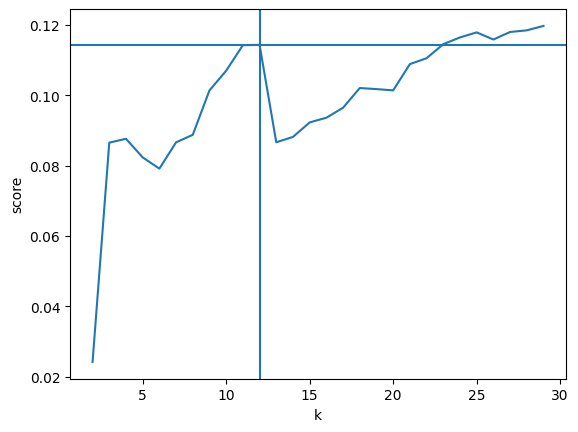

In [ ]:
sns.lineplot(data=params_1d, x = 'k', y = 'score')
plt.axhline(params_1d['score'].quantile(0.75))
plt.axvline(12)

In [ ]:
top_N

200

In [ ]:
top_genes = calculate_overlap(all_data, top_N)

D = pairwise_distances(top_genes.T.to_numpy(), metric="jaccard")

n_clusters = 12
model = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="precomputed",
    linkage="complete"
)

labels = model.fit_predict(D)

plot_df = top_genes.T
plot_df['label'] = labels
plot_df = plot_df.sort_values('label')

# get color bar
clusters = sorted(set(labels))
cluster_to_color = dict(
    zip(clusters, palette_25)
)
colors = plot_df['label'].map(cluster_to_color)
plot_df_out = plot_df.drop('label', axis=1)

genes_counts = plot_df.groupby('label').sum()
gene_total = plot_df.reset_index().groupby('label')['index'].count()
genes_counts = genes_counts.divide(gene_total, axis=0)

genes_retain = []
for label in genes_counts.index:
    s = genes_counts[genes_counts.index==label].T
    top = s[label].quantile(0.99)
    s = s[s[label]>top]
    genes_retain.append(s.index.tolist())
genes_retain = list(set([i for l in genes_retain for i in l]))

plot_df_out = plot_df_out[genes_retain]

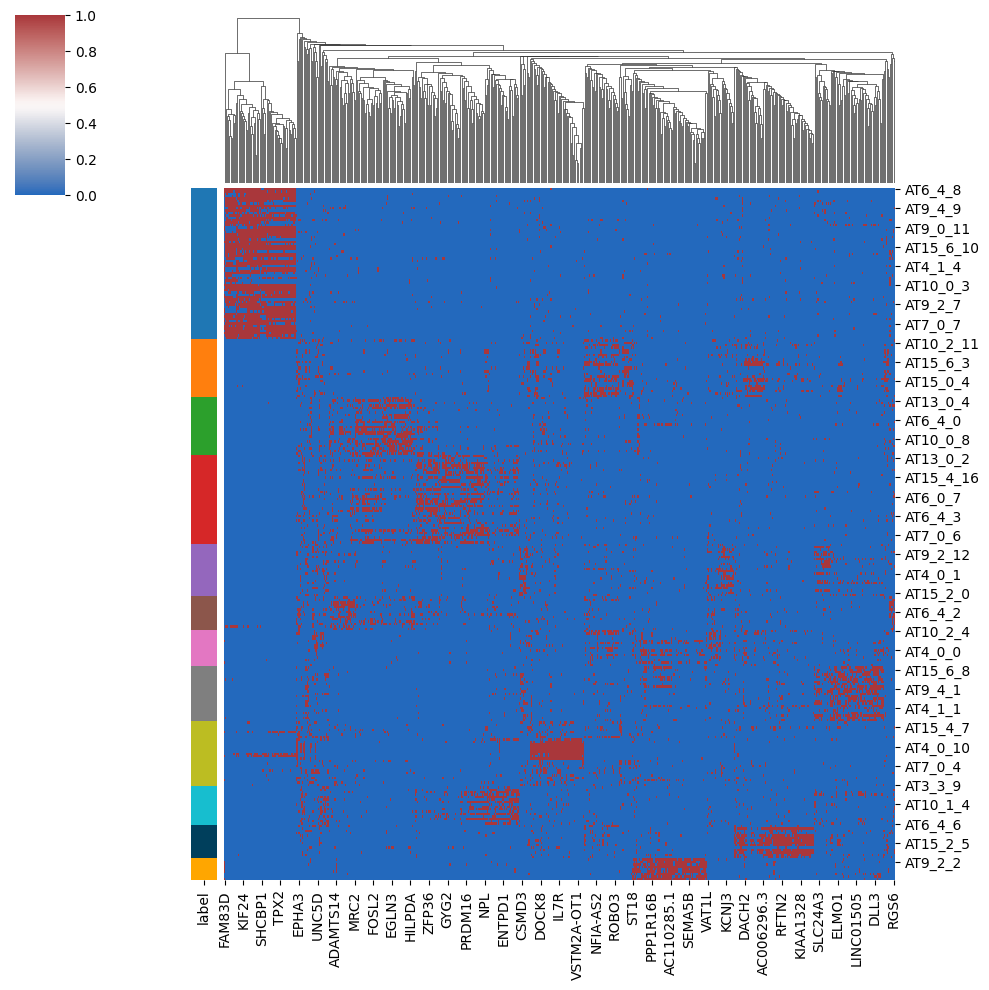

In [ ]:
sns.clustermap(plot_df_out, cmap='vlag', row_cluster=False, row_colors=colors)

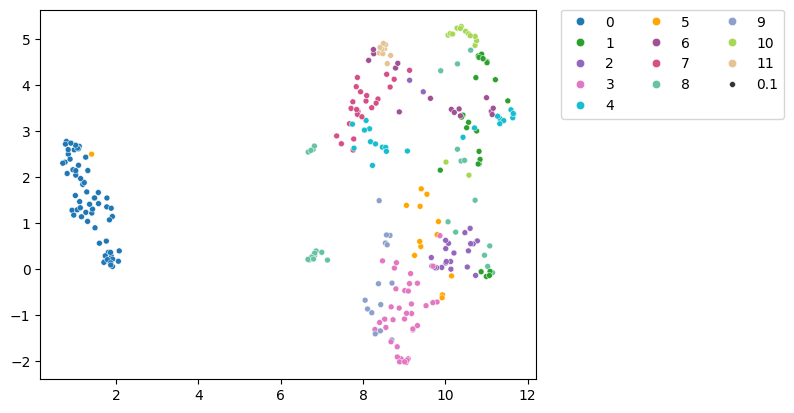

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
reducer = umap.UMAP(metric = "manhattan", random_state = 21)
embedding = reducer.fit_transform(top_genes.transpose())

labels_umap = labels
ax = sns.scatterplot(
x = embedding[:, 0],
y = embedding[:, 1], hue = labels_umap,  palette = cmap25,  
    legend="full",
    
    size=0.1)
plt.xticks(fontsize=10)  # Set x-axis tick font size
plt.yticks(fontsize=10)  # Set y-axis tick font size
ax.legend(
    bbox_to_anchor=(1.05, 1),  # Position to the right of the plot
    loc='upper left',         # Anchor the legend's upper-left corner
    ncol=3,
    fontsize=10,
    borderaxespad=0           # Padding between axes and legend
)
plt.show()

## Get factor gene list

In [ ]:
factor_genes = top_genes.T
factor_genes['label'] = labels

In [ ]:
gene_counts = factor_genes.groupby('label').sum()
factor_counts = factor_genes.reset_index().groupby('label')['index'].count()
factor_gene_prec = gene_counts.divide(factor_counts, axis=0).T

In [ ]:
perc_threshold = 0.3
factor_gene_dict = {}
for f in factor_gene_prec.columns:
    factor_ranks = factor_gene_prec[f].sort_values(ascending=False)
    factor_gene_dict[f] = factor_ranks[factor_ranks>perc_threshold].index.tolist()
    print(len(factor_ranks[factor_ranks>perc_threshold]))

193
66
83
86
77
68
77
138
88
137
148
207


In [ ]:
#factor_ranks[factor_ranks>perc_threshold]

<AxesSubplot:xlabel='label', ylabel='donor_id'>

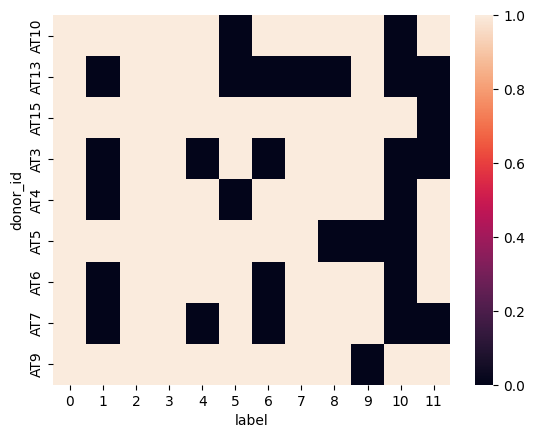

In [ ]:
# get donor spread per factor
factor_donors = factor_genes[['label']].reset_index()
factor_donors['donor_id'] = [re.sub('_.*$', '', i) for i in factor_donors['index']]
factor_donors = factor_donors.groupby(['donor_id', 'label'], as_index=False).count()\
.pivot(index = 'donor_id', columns = 'label', values = 'index').fillna(0)

sns.heatmap(factor_donors>0)

## Check atlas enrichment

In [ ]:
# malignant adata
adata = sc.read_h5ad('../../../data/GBM_LEAP_annotations/GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad')
adata = adata[adata.obs['cell_status']=='Malignant',].copy()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
# neftel
score_list = []
for m in factor_gene_dict.keys():
    sc.tl.score_genes(adata, factor_gene_dict[m], score_name=str(m)+'_score', use_raw=False)
    score_list.append(str(m)+'_score')

<AxesSubplot:ylabel='annotation_granular'>

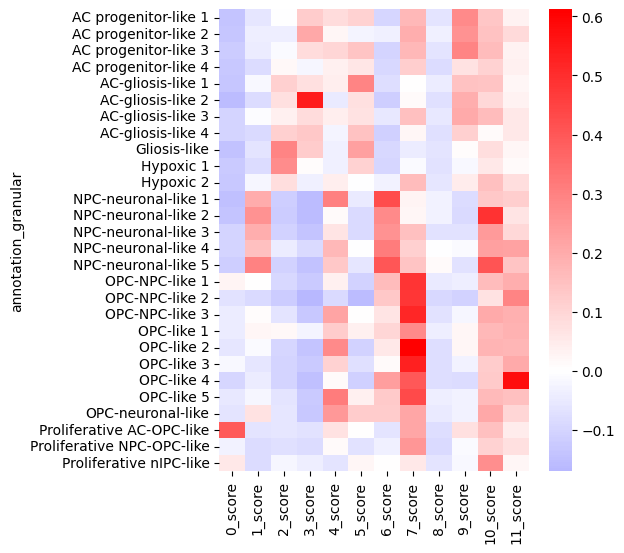

In [ ]:
module_scores = adata.obs\
    .groupby(['annotation_granular'])[score_list].mean()
plt.figure(figsize=(5, 6))
sns.heatmap(module_scores, cmap = 'bwr', center=0)

<AxesSubplot:ylabel='annotation_granular'>

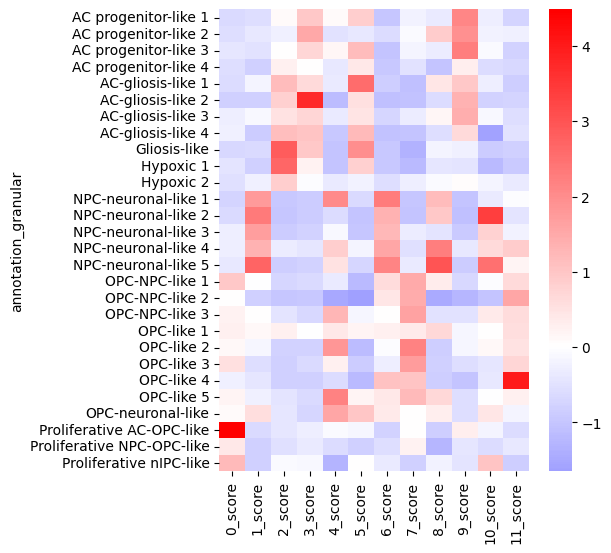

In [ ]:
module_scores = adata.obs\
    .groupby(['annotation_granular'])[score_list].mean()\
    .apply(zscore, axis=0)

plt.figure(figsize=(5, 6))
sns.heatmap(module_scores, cmap = 'bwr', center=0)

In [ ]:
annotation = {
    0:'Cycling',
    1:'NPC-neuronal-like 1',
    2:'Gliosis-hypoxia',
    3:'AC-gliosis-like 2',
    4:'NPC-OPC-like 2',
    5:'AC-gliosis-like 1',
    6:'NPC-neuronal-like 2',
    7:'NPC-OPC-like 1',
    8:'AC-NPC-OPC-like 1',
    9:'AC-progenitor-like',  
    10:'NPC-neuronal-like 3', 
    11:'OPC-like'
}

In [ ]:
output = {new_k: factor_gene_dict[old_k] for old_k, new_k in annotation.items()}

In [ ]:
wd = '../data/cell2fate_trajectories/'

In [ ]:
import pickle

with open(os.path.join(wd, "factor_genes_latest.pkl"), "wb") as f:
    pickle.dump(output, f)

In [ ]:
top_genes.to_csv(os.path.join(wd, "all_top_genes_latest.csv"))

In [ ]:
plot_df.to_csv(os.path.join(wd, "all_top_genes_labelled.csv"))